In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

competitions = pd.read_csv('competitions.csv')
appearances = pd.read_csv('appearances.csv')
players = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')

top_leagues = ['GB1', 'IT1', 'ES1', 'L1', 'FR1']
season_start_date = '2024-08-01'
season_end_date = '2025-06-30'
reference_year = 2024

In [2]:

#Filtering appearances for top leagues and the specified season
appearances['date'] = pd.to_datetime(appearances['date'])
app_filtered = appearances[
    (appearances['competition_id'].isin(top_leagues))
    & (appearances['date'] >= season_start_date)
    & (appearances['date'] <= season_end_date)
]

#Aggregating player statistics
stats = (
    app_filtered.groupby('player_id')
    .agg(
        appearances_count=('game_id', 'count'),
        minutes_played=('minutes_played', 'sum'),
        goals=('goals', 'sum'),
        assists=('assists', 'sum'),
    )
    .reset_index()
)

# Selecting only players with at least 900 minutes played
stats = stats[stats['minutes_played'] >= 900]

#Normalizing statistics per 90 minutes played
stats['goals_p90'] = (stats['goals'] / stats['minutes_played']) * 90
stats['assists_p90'] = (stats['assists'] / stats['minutes_played']) * 90
stats['goal_contributions_p90'] = (
    (stats['goals'] + stats['assists']) / stats['minutes_played']
) * 90

# Cleaning player data
players_clean = players[
    [
        'player_id',
        'date_of_birth',
        'position',
        'sub_position',
        'height_in_cm',
        'foot',
    ]
].copy()

#Excluding goalkeepers
players_clean = players_clean[players_clean['position'] != 'Goalkeeper']

#Calculating age
players_clean['birth_year'] = pd.to_datetime(
    players_clean['date_of_birth']
).dt.year
players_clean['age'] = reference_year - players_clean['birth_year']
players_clean = players_clean.drop(columns=['date_of_birth', 'birth_year'])

df = pd.merge(stats, players_clean, on='player_id', how='inner')

#Extracting the latest market values before and after the season
valuations['date'] = pd.to_datetime(valuations['date'])

val_pre = valuations[valuations['date'] < season_start_date]
latest_pre_val = (
    val_pre.sort_values('date')
    .groupby('player_id')
    .last()[['market_value_in_eur']]
    .reset_index()
    .rename(columns={'market_value_in_eur': 'prev_market_value_in_eur'})
)

val_post = valuations[
    (valuations['date'] >= '2025-01-01')
    & (valuations['date'] <= season_end_date)
]
latest_post_val = (
    val_post.sort_values('date')
    .groupby('player_id')
    .last()[['market_value_in_eur']]
    .reset_index()
)

df = pd.merge(df, latest_pre_val, on='player_id', how='inner')
df = pd.merge(df, latest_post_val, on='player_id', how='inner')

df = df[
    (df['market_value_in_eur'] > 0) & (df['prev_market_value_in_eur'] > 0)
].dropna()

df['prev_target_log_val'] = np.log1p(df['prev_market_value_in_eur'])
df['target_log_val'] = np.log1p(df['market_value_in_eur'])


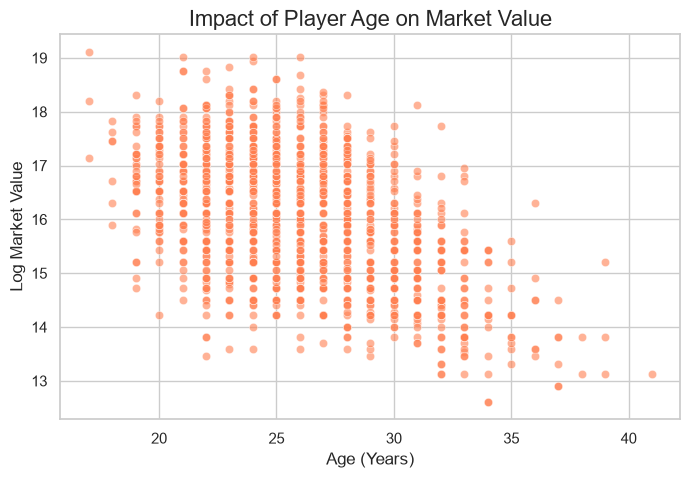

In [3]:
# Imposta uno stile pulito per i grafici
sns.set_theme(style="whitegrid")

# 2. Scatterplot per la Feature Selection (Età vs Valore)
plt.figure(figsize=(8, 5))
# Usiamo uno scatterplot per mostrare la correlazione (richiesto in Q2.4)
sns.scatterplot(x='age', y='target_log_val', data=df, alpha=0.6, color='coral')
plt.title('Impact of Player Age on Market Value', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Log Market Value', fontsize=12)
plt.show()


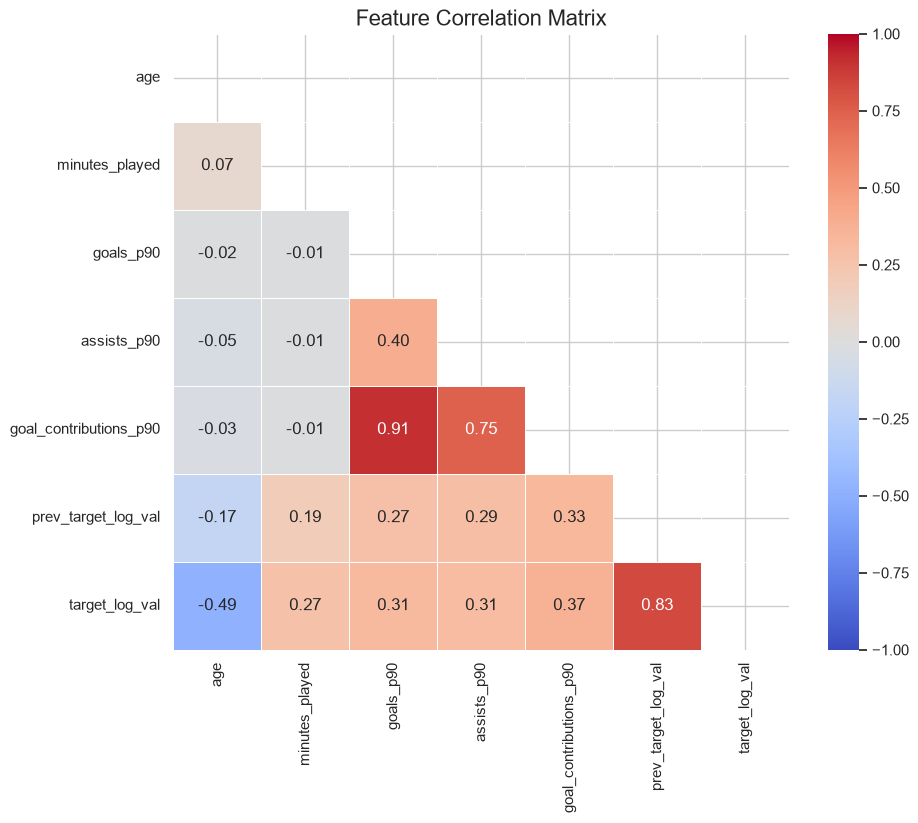

In [ ]:
    # 3. Heatmap di Correlazione (Feature Selection & Multicollinearità)
plt.figure(figsize=(10, 8))

# Seleziona solo le colonne numeriche per la correlazione
numeric_cols = [
    'age', 'minutes_played', 'goals_p90', 'assists_p90', 
    'goal_contributions_p90', 'prev_target_log_val', 'target_log_val'
]
corr_matrix = df[numeric_cols].corr()

# Crea una maschera per nascondere la metà superiore (ridondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Disegna la heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()